In [1]:
import csv
import functools
import os
import random
import shelve
from concurrent import futures

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from synthetic.model import Layer, RandomValue, do_synthetic, trim, normalise, rmse, r2, resample_y

In [2]:
DATA_DIR = "../data"
datafile = functools.partial(os.path.join, DATA_DIR)
mean_rf_t, mean_rf_y = np.load(datafile("mean_rf.npy"))
random.seed(100)
iterations = 5000
top_n = int(0.05 * iterations)
colours = ("red", "green", "cyan", "orange")

In [53]:
mx, my = trim(0, 10, mean_rf_t, mean_rf_y)

two_layer_rand_model = [
    Layer(thickness=RandomValue(1500, 15000, 50), rho=2100, v_p=3000, v_s=1000),
    Layer(thickness=RandomValue(5000, 25000, 50), rho=2304, v_p=3800, v_s=1850),
    Layer(thickness=0, rho=2863, v_p=6220, v_s=3750),
]

three_layer_rand_model = [
    Layer(thickness=RandomValue(1500, 15000, 50), v_p=3800, v_s=1850, rho=2304),
    Layer(thickness=RandomValue(5000, 15000, 50), v_p=4500, v_s=2800, rho=2570),
    Layer(thickness=RandomValue(5000, 20000, 50), v_p=6220, v_s=3750, rho=2863),
    Layer(thickness=0, v_p=7670, v_s=4330, rho=3446),
]

four_layer_rand_model_slow = [
    Layer(thickness=1000, v_p=2800, v_s=1500, rho=2100),
    Layer(thickness=RandomValue(1500, 15000, 50), v_p=3800, v_s=1850, rho=2304),
    Layer(thickness=RandomValue(5000, 15000, 50), v_p=4500, v_s=2800, rho=2570),
    Layer(thickness=RandomValue(5000, 20000, 50), v_p=6220, v_s=3750, rho=2863),
    Layer(thickness=0, v_p=7670, v_s=4330, rho=3446),
]

four_layer_rand_model_fast = [
    Layer(thickness=2000, v_p=5000, v_s=3000, rho=2500),
    Layer(thickness=RandomValue(1500, 15000, 50), v_p=3800, v_s=1850, rho=2304),
    Layer(thickness=RandomValue(5000, 15000, 50), v_p=4500, v_s=2800, rho=2570),
    Layer(thickness=RandomValue(5000, 20000, 50), v_p=6220, v_s=3750, rho=2863),
    Layer(thickness=0, v_p=7670, v_s=4330, rho=3446),
]


def run_params(filename: str, layers: [Layer]):
    fields = [
        "rmse", "r^2",
        *[f"{t}{i + 1}" for i in range(len(layers)) for t in ("thick", "depth", "v_p", "v_s", "rho")]
    ]
    with open(datafile(f"rand_models/{filename}.csv"), "w") as file:
        writer = csv.DictWriter(file, dialect='unix', fieldnames=fields)
        writer.writeheader()
        for i in range(iterations):
            ll = [l.resolve() for l in layers]
            xx, yy, model = do_synthetic(ll)
            xx, yy = trim(0, 10, *normalise(xx, yy))
            y1, y2 = resample_y(xx, yy, mx, my)
            thk = {f"thick{i + 1}": v.thickness for i, v in enumerate(ll)}
            v_s = {f"v_s{i + 1}": v.v_s for i, v in enumerate(ll)}
            v_p = {f"v_p{i + 1}": v.v_p for i, v in enumerate(ll)}
            rho = {f"rho{i + 1}": v.rho for i, v in enumerate(ll)}
            dpt = {f"depth{i}": sum(l.thickness for l in ll[:i]) for i in range(1, len(ll))}
            writer.writerow(
                {"rmse": rmse(y1, y2), "r^2": r2(y1, y2)} | thk | dpt | v_s | v_p | rho
            )
    print(f"{filename} done")

In [54]:
# run_params("two_layer", two_layer_rand_model)

jobs = (
    ("two_layer", two_layer_rand_model),
    ("three_layer", three_layer_rand_model),
    ("four_layer_slow", four_layer_rand_model_slow),
    ("four_layer_fast", four_layer_rand_model_fast),
)

ex = futures.ProcessPoolExecutor(max_workers=4)
wg = [ex.submit(run_params, *job) for job in jobs]
ex.shutdown()

three_layer done
two_layer done
four_layer_slow done
four_layer_fast done


In [3]:
l2_df = pd.read_csv(datafile("rand_models/two_layer.csv")).sort_values("rmse", ascending=True)
l3_df = pd.read_csv(datafile("rand_models/three_layer.csv")).sort_values("rmse", ascending=True)
l4s_df = pd.read_csv(datafile("rand_models/four_layer_slow.csv")).sort_values("rmse", ascending=True)
l4f_df = pd.read_csv(datafile("rand_models/four_layer_fast.csv")).sort_values("rmse", ascending=True)
l2_df

,rmse,r^2,thick1,depth1,v_p1,v_s1,rho1,thick2,depth2,v_p2,v_s2,rho2,thick3,depth3,v_p3,v_s3,rho3
3231,0.123129,0.225570,10550.0,10550.0,3000,1000,2100,15000.0,25550.0,3800,1850,2304,0,NaN,6220,3750,2863
1695,0.123133,0.225540,10600.0,10600.0,3000,1000,2100,15300.0,25900.0,3800,1850,2304,0,NaN,6220,3750,2863
70,0.123148,0.225443,10550.0,10550.0,3000,1000,2100,14750.0,25300.0,3800,1850,2304,0,NaN,6220,3750,2863
2820,0.123161,0.225331,10550.0,10550.0,3000,1000,2100,16250.0,26800.0,3800,1850,2304,0,NaN,6220,3750,2863
361,0.123171,0.225262,10600.0,10600.0,3000,1000,2100,16700.0,27300.0,3800,1850,2304,0,NaN,6220,3750,2863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1204,1.187666,0.068354,2250.0,2250.0,3000,1000,2100,5350.0,7600.0,3800,1850,2304,0,NaN,6220,3750,2863
1933,1.188133,0.106731,2100.0,2100.0,3000,1000,2100,5450.0,7550.0,3800,1850,2304,0,NaN,6220,3750,2863
4234,1.188133,0.106731,2100.0,2100.0,3000,1000,2100,5500.0,7600.0,3800,1850,2304,0,NaN,6220,3750,2863
3096,1.203782,0.077295,2250.0,2250.0,3000,1000,2100,5200.0,7450.0,3800,1850,2304,0,NaN,6220,3750,2863


In [56]:
l3_df

,rmse,r^2,thick1,depth1,v_p1,v_s1,rho1,thick2,depth2,v_p2,...,thick3,depth3,v_p3,v_s3,rho3,thick4,depth4,v_p4,v_s4,rho4
4848,0.081396,0.538617,8900.0,8900.0,3800,1850,2304,14000.0,22900.0,4500,...,5000.0,27900.0,6220,3750,2863,0,NaN,7670,4330,3446
3917,0.082816,0.530429,9100.0,9100.0,3800,1850,2304,14050.0,23150.0,4500,...,5150.0,28300.0,6220,3750,2863,0,NaN,7670,4330,3446
2086,0.082971,0.526456,8800.0,8800.0,3800,1850,2304,14050.0,22850.0,4500,...,5050.0,27900.0,6220,3750,2863,0,NaN,7670,4330,3446
4557,0.086016,0.558704,9600.0,9600.0,3800,1850,2304,14700.0,24300.0,4500,...,19800.0,44100.0,6220,3750,2863,0,NaN,7670,4330,3446
3632,0.086298,0.504287,8600.0,8600.0,3800,1850,2304,14600.0,23200.0,4500,...,6000.0,29200.0,6220,3750,2863,0,NaN,7670,4330,3446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4558,527.407320,0.107437,4950.0,4950.0,3800,1850,2304,6050.0,11000.0,4500,...,6400.0,17400.0,6220,3750,2863,0,NaN,7670,4330,3446
2663,709.525134,0.008885,3100.0,3100.0,3800,1850,2304,7500.0,10600.0,4500,...,5900.0,16500.0,6220,3750,2863,0,NaN,7670,4330,3446
3048,992.843152,0.000046,1500.0,1500.0,3800,1850,2304,9500.0,11000.0,4500,...,9350.0,20350.0,6220,3750,2863,0,NaN,7670,4330,3446
2943,2517.952878,0.168762,4650.0,4650.0,3800,1850,2304,5100.0,9750.0,4500,...,6600.0,16350.0,6220,3750,2863,0,NaN,7670,4330,3446


In [57]:
l4s_df

,rmse,r^2,thick1,depth1,v_p1,v_s1,rho1,thick2,depth2,v_p2,...,thick4,depth4,v_p4,v_s4,rho4,thick5,depth5,v_p5,v_s5,rho5
3568,0.091093,0.522368,1000,1000,2800,1500,2100,8100.0,9100.0,3800,...,19200.0,42750.0,6220,3750,2863,0,NaN,7670,4330,3446
4411,0.092251,0.512342,1000,1000,2800,1500,2100,8500.0,9500.0,3800,...,19500.0,43250.0,6220,3750,2863,0,NaN,7670,4330,3446
123,0.093223,0.493933,1000,1000,2800,1500,2100,7350.0,8350.0,3800,...,5200.0,28200.0,6220,3750,2863,0,NaN,7670,4330,3446
2019,0.093457,0.493423,1000,1000,2800,1500,2100,7500.0,8500.0,3800,...,5650.0,29050.0,6220,3750,2863,0,NaN,7670,4330,3446
863,0.093791,0.490631,1000,1000,2800,1500,2100,7700.0,8700.0,3800,...,5750.0,28950.0,6220,3750,2863,0,NaN,7670,4330,3446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,1203.551049,0.002301,1000,1000,2800,1500,2100,2850.0,3850.0,3800,...,8750.0,18650.0,6220,3750,2863,0,NaN,7670,4330,3446
3017,2200.837351,0.022972,1000,1000,2800,1500,2100,2900.0,3900.0,3800,...,7350.0,16800.0,6220,3750,2863,0,NaN,7670,4330,3446
3524,2229.691954,0.001506,1000,1000,2800,1500,2100,2850.0,3850.0,3800,...,9050.0,18550.0,6220,3750,2863,0,NaN,7670,4330,3446
994,2232.596911,0.001299,1000,1000,2800,1500,2100,2950.0,3950.0,3800,...,11050.0,20300.0,6220,3750,2863,0,NaN,7670,4330,3446


In [58]:
l4f_df

,rmse,r^2,thick1,depth1,v_p1,v_s1,rho1,thick2,depth2,v_p2,...,thick4,depth4,v_p4,v_s4,rho4,thick5,depth5,v_p5,v_s5,rho5
1624,0.126113,0.203329,2000,2000,5000,3000,2500,8200.0,10200.0,3800,...,5300.0,30350.0,6220,3750,2863,0,NaN,7670,4330,3446
1394,0.129298,0.183945,2000,2000,5000,3000,2500,8400.0,10400.0,3800,...,5350.0,29200.0,6220,3750,2863,0,NaN,7670,4330,3446
863,0.129316,0.183374,2000,2000,5000,3000,2500,7700.0,9700.0,3800,...,5750.0,29950.0,6220,3750,2863,0,NaN,7670,4330,3446
2019,0.130307,0.177301,2000,2000,5000,3000,2500,7500.0,9500.0,3800,...,5650.0,30050.0,6220,3750,2863,0,NaN,7670,4330,3446
921,0.130993,0.174385,2000,2000,5000,3000,2500,8650.0,10650.0,3800,...,18500.0,43750.0,6220,3750,2863,0,NaN,7670,4330,3446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3345,221.330150,0.131183,2000,2000,5000,3000,2500,2600.0,4600.0,3800,...,7150.0,17700.0,6220,3750,2863,0,NaN,7670,4330,3446
2064,233.251360,0.067006,2000,2000,5000,3000,2500,2250.0,4250.0,3800,...,10500.0,19850.0,6220,3750,2863,0,NaN,7670,4330,3446
1345,328.878600,0.079719,2000,2000,5000,3000,2500,2050.0,4050.0,3800,...,8850.0,18000.0,6220,3750,2863,0,NaN,7670,4330,3446
290,1029.210424,0.084200,2000,2000,5000,3000,2500,2450.0,4450.0,3800,...,8400.0,19600.0,6220,3750,2863,0,NaN,7670,4330,3446


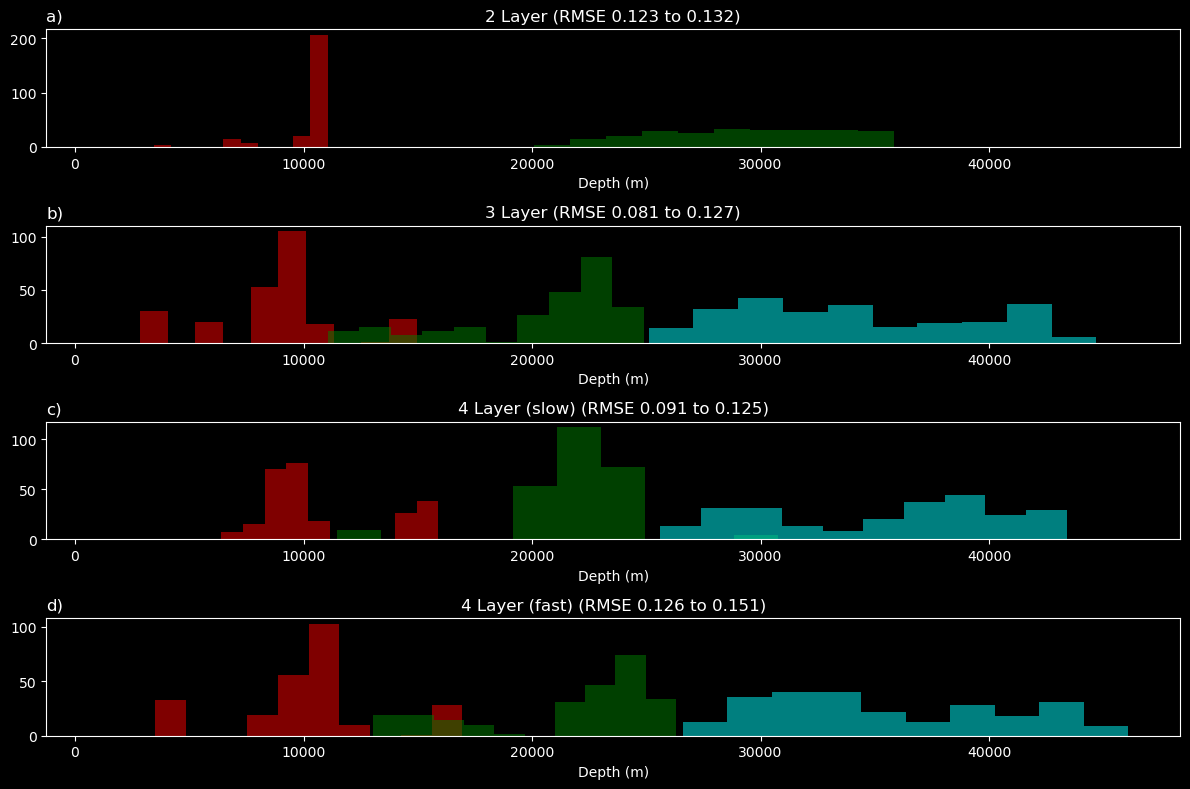

In [4]:
with plt.style.context("dark_background"):
    fig, axs = plt.subplots(4, 1, figsize=(12, 8), dpi=100, sharex=True)
    
for ax in axs:
    ax.tick_params(labelbottom=True)
    ax.set_xlabel("Depth (m)")
# top_n = 10

axs[0].set_title(f"2 Layer (RMSE {l2_df.head(top_n).rmse.min():.3f} to {l2_df.head(top_n).rmse.max():.3f})")
axs[0].set_title("a)", loc="left")
axs[0].hist(l2_df.head(top_n).depth1, color=colours[0], alpha=.5)
axs[0].hist(l2_df.head(top_n).depth2, color=colours[1], alpha=.5)
# axs[0].axvline(l2_df.head(top_n).depth1.mean(), color="k")
# axs[0].axvline(l2_df.head(top_n).depth2.mean(), color="k")

axs[1].set_title(f"3 Layer (RMSE {l3_df.head(top_n).rmse.min():.3f} to {l3_df.head(top_n).rmse.max():.3f})")
axs[1].set_title("b)", loc="left")
axs[1].hist(l3_df.head(top_n).depth1, color=colours[0], alpha=.5)
axs[1].hist(l3_df.head(top_n).depth2, color=colours[1], alpha=.5)
axs[1].hist(l3_df.head(top_n).depth3, color=colours[2], alpha=.5)
# axs[1].axvline(l3_df.head(top_n).depth1.mean(), color="k")
# axs[1].axvline(l3_df.head(top_n).depth2.mean(), color="k")
# axs[1].axvline(l3_df.head(top_n).depth3.mean(), color="k")

axs[2].set_title(f"4 Layer (slow) (RMSE {l4s_df.head(top_n).rmse.min():.3f} to {l4s_df.head(top_n).rmse.max():.3f})")
axs[2].set_title("c)", loc="left")
axs[2].hist(l4s_df.head(top_n).depth2, color=colours[0], alpha=.5)
axs[2].hist(l4s_df.head(top_n).depth3, color=colours[1], alpha=.5)
axs[2].hist(l4s_df.head(top_n).depth4, color=colours[2], alpha=.5)
axs[2].axvline(l4s_df.head(top_n).depth1.mean(), color="k")
# axs[2].axvline(l4s_df.head(top_n).depth2.mean(), color="k")
# axs[2].axvline(l4s_df.head(top_n).depth3.mean(), color="k")
# axs[2].axvline(l4s_df.head(top_n).depth4.mean(), color="k")

axs[3].set_title(f"4 Layer (fast) (RMSE {l4f_df.head(top_n).rmse.min():.3f} to {l4f_df.head(top_n).rmse.max():.3f})")
axs[3].set_title("d)", loc="left")
axs[3].hist(l4f_df.head(top_n).depth2, color=colours[0], alpha=.5)
axs[3].hist(l4f_df.head(top_n).depth3, color=colours[1], alpha=.5)
axs[3].hist(l4f_df.head(top_n).depth4, color=colours[2], alpha=.5)
axs[3].axvline(l4f_df.head(top_n).depth1.mean(), color="k")
# axs[3].axvline(l4f_df.head(top_n).depth2.mean(), color="k")
# axs[3].axvline(l4f_df.head(top_n).depth3.mean(), color="k")
# axs[3].axvline(l4f_df.head(top_n).depth4.mean(), color="k")

fig.tight_layout()
fig.savefig(datafile("figures/hist.png"))

In [60]:
def mean_model(df: pd.DataFrame, layer_count: int) -> [Layer]:
    return [Layer(
        thickness=df[f"thick{i + 1}"].mean(),
        rho=df[f"rho{i + 1}"].mean(),
        v_p=df[f"v_p{i + 1}"].mean(),
        v_s=df[f"v_s{i + 1}"].mean(),
    ) for i in range(layer_count)]


def best_model(df: pd.DataFrame, layer_count: int) -> [Layer]:
    return [Layer(
        thickness=df.head(1)[f"thick{i + 1}"].mean(),
        rho=df.head(1)[f"rho{i + 1}"].mean(),
        v_p=df.head(1)[f"v_p{i + 1}"].mean(),
        v_s=df.head(1)[f"v_s{i + 1}"].mean(),
    ) for i in range(layer_count)]


models = shelve.open(datafile("models"))
models["mean_two_layer"] = mean_model(l2_df.head(top_n), 3)
models["mean_three_layer"] = mean_model(l3_df.head(top_n), 3)
models["mean_four_layer_slow"] = mean_model(l4s_df.head(top_n), 3)
models["mean_four_layer_fast"] = mean_model(l4f_df.head(top_n), 3)
models["best_two_layer"] = best_model(l2_df.head(top_n), 3)
models["best_three_layer"] = best_model(l3_df.head(top_n), 3)
models["best_four_layer_slow"] = best_model(l4s_df.head(top_n), 3)
models["best_four_layer_fast"] = best_model(l4f_df.head(top_n), 3)
models.close()